# ESA ClouDInSAR - InSAR Workflow Input Selection

**Authors:**  
_Mattia Callegari, Eurac Research_  
_Michele Claus, Eurac Research_

**Release Date:**  
May 06, 2025

## Objectives:
- Learn how to interact with the CDSE burst catalog, performing a query based on your temporal and spatial range of interest.

- Understand why accessing single bursts can optimize your workflow.

- Filter the desired products based on track and polarization.

- Get the perpendicular and temporal baseline of the selected product pairs and select only the required for our analysis.

- Finally, define the input parameters required by the openEO workflow: polarization, burst Id, subswath, InSAR pairs list.

## Setup

Open the python notebook in CDSE JupyterLab and select the `esa-snap` kernel. Then install some additional needed libraries:

In [1]:
pip install shapely folium leafmap

  Using cached pystac_client-0.9.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached pystac-1.14.3-py3-none-any.whl.metadata (4.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.8/666.8 kB 23.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 73.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 117.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 34.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.8/889.8 kB 38.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.9 MB/s  0:00:00
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 48.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 83.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.0 MB/s 

## Import the `s1_burst_lib` python module

In [2]:
import s1_burst_lib
from IPython.display import JSON

ModuleNotFoundError: No module named 'esa_snappy'

## Input definition

Select polarization and the temporal range of interest defining the start and end dates

In [3]:
pol = "VV"
start_date = "2024-01-01"
end_date = "2025-01-30"

Define an area of interest by drawing in the map using the rectangle selection tool

In [5]:
m = leafmap.Map(center=(47.005, 11.507), zoom=7.5)
m

Map(center=[47.005, 11.507], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

In [ ]:
feat = m.draw_features
geom_dict = feat[0]['geometry']
geom = shape(geom_dict)
aoi = geom.wkt
# Or provide it manually:
# aoi = "POLYGON ((11.28 46.47, 11.28 46.52, 11.44 46.52, 11.44 46.47, 11.28 46.47))" # e.g. 'POLYGON ((11.28 46.47, 11.28 46.52, 11.44 46.52, 11.44 46.47, 11.28 46.47))'

'POLYGON ((11.274376 46.456829, 11.274376 46.520887, 11.413078 46.520887, 11.413078 46.456829, 11.274376 46.456829))'

## 2. CDSE Bursts Catalog Query

Retrieve the bursts info with an https request to the CDSE OData API.

In [ ]:
s1_bursts = s1_burst_lib.retrieve_bursts(start_date, end_date, pol, aoi)

<IPython.core.display.JSON object>

## Show On Map

Show the Sentinel-1 bursts on a map.

In [ ]:
m = s1_burst_lib.show_bursts(s1_bursts, aoi)
m

## Plot Acquisition Calendar

To understand the result of our data query for Sentinel-1, we plot here a visual calendar showing on which date the corresponding track has been acquired.

In [ ]:
s1_burst_lib.show_acquisition_calendar(s1_bursts)

## Filter with Track, Burst ID and Polarization

Now we can select the necessary parameters we will need in our openEO workflow.  
Select one of the available sub_swath_identifier (i.e. iw1, iw2, iw3) and burstId from the following list or from the map widget above.

In [13]:
for x in children:
  print(x["label"])
  for y in x["children"]:
    print("  " + y["label"]) 

Track 117
  BurstId: 249433, IW2
  BurstId: 249434, IW2
Track 95
  BurstId: 202703, IW3
  BurstId: 202704, IW3
Track 168
  BurstId: 359501, IW1
  BurstId: 359502, IW1


Set the required polarization, subswath identifier and correspondant burst id.  
Currently we have to select only a single burst due to a limitation of the current implementation.

In [14]:
sub_swath_identifier = "iw2"
burst_id = "249434"
polarization = "VV"

## Download Sentinel-1 metadata

Get the metadata from the S3 bucket. You need to insert your [CDSE S3 credentials](https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials).  
The code in the next cell will download only the necessary metadata files required to compute the perpendicular baseline using the ESA SNAP toolbox.  
It will also create empty geotiff images and replicate the folder structure of a full Sentinel-1 product stored with the SAFE format. This will allow us to use SNAP for this task.

In [ ]:
CDSE_ACCESS_KEY = ""
CDSE_SECRET_KEY = ""

s1_fileList = s1_burst_lib.download_s1metadata(s1_bursts, sub_swath_identifier, burst_id, CDSE_ACCESS_KEY, CDSE_SECRET_KEY)
s1_fileList

### InSAR pair list for SBAS (Small Baseline Subset) configuration

In [ ]:
sbas_pairs = s1_burst_lib.sbas_pairs(s1_fileList, max_temporal_baseline=24, max_perp_baseline=200)

Perp Baseline: 0.0
Perp Baseline: 32.158416748046875
Perp Baseline: -46.4830207824707
Perp Baseline: 45.744422912597656
Perp Baseline: 49.67479705810547
Perp Baseline: 54.089019775390625
Perp Baseline: -25.899009704589844
Perp Baseline: -74.0414047241211
Perp Baseline: 232.1392822265625
Perp Baseline: 106.1134033203125
Perp Baseline: 117.61506652832031
Perp Baseline: 181.58047485351562
Perp Baseline: 312.0473327636719
Perp Baseline: 420.40911865234375
Perp Baseline: 325.82537841796875
Perp Baseline: 383.9298400878906
Perp Baseline: 193.76785278320312
Perp Baseline: 147.13941955566406
Perp Baseline: -23.79122543334961
Perp Baseline: 271.9586181640625
Perp Baseline: -41.44721603393555
Perp Baseline: 147.72279357910156
Perp Baseline: 230.59449768066406
Perp Baseline: 229.99429321289062
Perp Baseline: -220.82583618164062
Perp Baseline: 163.4061737060547
Perp Baseline: 134.44369506835938
Perp Baseline: 105.18638610839844
Perp Baseline: -23.17386245727539
Perp Baseline: 137.2498016357422
Per

### InSAR pair list for PS (Persistent Scatterer) configuration

INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
/home/mcallegari/anaconda3/envs/cloudinsar/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


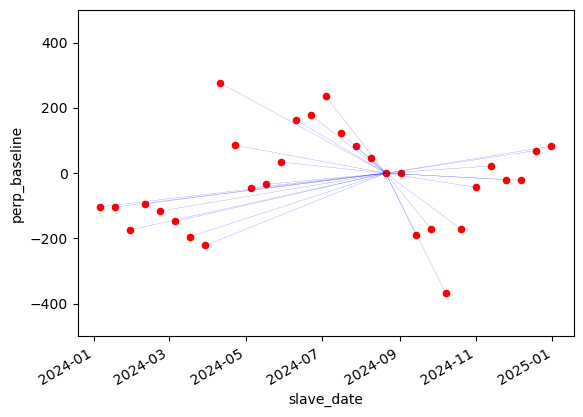

[['2024-08-21', '2024-03-06'],
 ['2024-08-21', '2024-02-23'],
 ['2024-08-21', '2024-03-18'],
 ['2024-08-21', '2024-01-06'],
 ['2024-08-21', '2024-01-18'],
 ['2024-08-21', '2024-02-11'],
 ['2024-08-21', '2024-01-30'],
 ['2024-08-21', '2024-03-30'],
 ['2024-08-21', '2024-04-23'],
 ['2024-08-21', '2024-05-05'],
 ['2024-08-21', '2024-05-17'],
 ['2024-08-21', '2024-05-29'],
 ['2024-08-21', '2024-06-10'],
 ['2024-08-21', '2024-04-11'],
 ['2024-08-21', '2024-06-22'],
 ['2024-08-21', '2024-07-04'],
 ['2024-08-21', '2024-08-09'],
 ['2024-08-21', '2024-09-02'],
 ['2024-08-21', '2024-09-26'],
 ['2024-08-21', '2024-07-16'],
 ['2024-08-21', '2024-09-14'],
 ['2024-08-21', '2024-07-28'],
 ['2024-08-21', '2024-12-31'],
 ['2024-08-21', '2024-10-08'],
 ['2024-08-21', '2024-11-13'],
 ['2024-08-21', '2024-12-07'],
 ['2024-08-21', '2024-11-01'],
 ['2024-08-21', '2024-10-20'],
 ['2024-08-21', '2024-11-25'],
 ['2024-08-21', '2024-12-19']]

In [ ]:
ps_pairs = s1_burst_lib.ps_pairs(s1_fileList)

## Recap

In this notebook we were able to interact with CDSE and its API to define the necessary parameters for the Sentinel-1 InSAR workflow we will run with openEO.

The selected parameters are:

In [ ]:
print(f"Selected polarization: {polarization}")
print(f"Selected subswath: {sub_swath_identifier}")
print(f"Selected burst id: {burst_id}")
print(f"Selected InSAR date pairs for SBAS:")
print(*sbas_pairs,sep='\n')
print(f"\nSelected InSAR date pairs for PS:")
print(*ps_pairs,sep='\n')

Selected polarization: VV
Selected subswath: iw2
Selected burst id: 249434
Selected InSAR date pairs for SBAS:
20240306_20240306
20240306_20240223
20240306_20240318
20240306_20240211
20240306_20240330
20240223_20240306
20240223_20240223
20240223_20240318
20240223_20240211
20240223_20240130
20240318_20240306
20240318_20240223
20240318_20240318
20240318_20240330
20240106_20240106
20240106_20240118
20240106_20240130
20240118_20240106
20240118_20240118
20240118_20240211
20240118_20240130
20240211_20240306
20240211_20240223
20240211_20240118
20240211_20240211
20240211_20240130
20240130_20240223
20240130_20240106
20240130_20240118
20240130_20240211
20240130_20240130
20240330_20240306
20240330_20240318
20240330_20240330
20240423_20240423
20240423_20240505
20240423_20240517
20240423_20240411
20240505_20240423
20240505_20240505
20240505_20240517
20240505_20240529
20240517_20240423
20240517_20240505
20240517_20240517
20240517_20240529
20240517_20240610
20240529_20240505
20240529_20240517
2024052